# Grid of mean 2D templates for all opto-tagged DRN units

Combines the 2D (channels x time) template view of `inspect_2d_waveforms_DRN.ipynb` with the
grid layout of `F_waveform_space_DRN_v2.ipynb` (section 6.5).

**What it does**
1. Loads `combined_unit_tbl.pkl` and applies the tagging/QC criteria (`waveform_low_DRN`) to get
   every opto-tagged unit across all DRN sessions.
2. For each session, opens the postprocessed analyzer once and pulls the mean template on the
   10 channels closest to the peak channel (same probe column, within the unit's sparsity mask).
3. Caches the extracted templates, then draws all units as one grid of 2D heatmaps.

No individual-spike / raw-trace panels: mean template only, so no recording is loaded.

## 1. Imports

In [6]:
import os
import sys
import json
import pickle

sys.path.append('/root/capsule/code/beh_ephys_analysis')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

import spikeinterface as si
from joblib import Parallel, delayed

from utils.beh_functions import session_dirs
from utils.combine_tools import apply_qc
from utils.capsule_migration import capsule_directories

capsule_dirs = capsule_directories()
%matplotlib inline

## 2. Configuration

In [7]:
# ==================== USER CONFIGURATION ====================
criteria_name = 'waveform_low_DRN'   # criteria json in session_combine/metrics
data_type = 'raw'                    # analyzer flavor to read templates from
n_channels_to_show = 10              # channels closest to the peak channel
normalize_each_panel = True          # scale every panel by its own |max| (shape, not amplitude)
force_recompute = False              # ignore the cache and re-read all analyzers
n_jobs = 8                           # sessions extracted in parallel
label_fontsize = 5                   # per-panel title size

target_folder = os.path.join(capsule_dirs['manuscript_fig_dir'], 'inspect_2d_waveforms_grid_DRN')
cache_folder = os.path.join(capsule_dirs['manuscript_fig_prep_dir'], 'waveforms_2d')
os.makedirs(target_folder, exist_ok=True)
os.makedirs(cache_folder, exist_ok=True)

cache_file = os.path.join(
    cache_folder,
    f'tagged_2d_templates_{criteria_name}_{data_type}_{n_channels_to_show}ch.pkl',
)
# ============================================================

## 3. Select opto-tagged units across sessions

In [8]:
combined_unit_file = os.path.join(
    capsule_dirs['manuscript_fig_prep_dir'], 'combined_unit_tbl', 'combined_unit_tbl.pkl'
)
criteria_file = os.path.join(
    '/root/capsule/code/beh_ephys_analysis/session_combine/metrics', f'{criteria_name}.json'
)

with open(combined_unit_file, 'rb') as f:
    combined_tagged_units = pickle.load(f)
with open(criteria_file, 'r') as f:
    constraints = json.load(f)

tagged_units, combined_tagged_units, fig, axes = apply_qc(combined_tagged_units, constraints)
fig.savefig(os.path.join(target_folder, 'quality_metrics.pdf'), bbox_inches='tight')
plt.close(fig)

tagged_units = tagged_units.sort_values(['session', 'unit']).reset_index(drop=True)

print(f'Tagged units passing {criteria_name}: {len(tagged_units)}')
print(f'Sessions: {tagged_units.session.nunique()}')

Applying bounds for isi_violations: [0.0, 0.1]
 - isi_violations: 951 -> 561 units passed
Applying items for qc_pass: [True]
 - qc_pass: 561 -> 469 units passed
Applying bounds for peak: [-1000, -0.1]
 - peak: 469 -> 430 units passed
Applying items for probe: [2]
 - probe: 430 -> 430 units passed
Applying opto conditions: ['p_max', 'eu', 'corr', 'tag_loc', 'lat_max_p', 'p_mean', 'sig_counts']
Number of opto rows after filtering: 207
Number of non-opto rows after filtering: 430
Tagged units passing waveform_low_DRN: 207
Sessions: 41


## 4. Template extraction

`unit_template_2d` reproduces the channel selection of `inspect_2d_waveforms_DRN.ipynb`: keep the
channels inside the unit's sparsity mask, restrict to the probe column carrying the peak channel,
then take the `n_channels` closest to the peak in channel index. The mean waveform comes from the
`templates` extension (`operator='average'`), which is the mean over the spikes the analyzer
sampled, so no per-spike waveform arrays need to be read.

In [9]:
def unit_template_2d(analyzer, template_ext, unit_id, right_left, n_channels):
    """Mean template (time x channels) on the channels closest to the unit's peak channel."""
    template = template_ext.get_unit_template(unit_id, operator='average')  # (time, all channels)

    if analyzer.sparsity is not None:
        unit_channels_ind = analyzer.sparsity.unit_id_to_channel_indices[unit_id]
    else:
        unit_channels_ind = np.arange(template.shape[1])

    peak_channel_ind = unit_channels_ind[np.argmax(np.ptp(template[:, unit_channels_ind], axis=0))]

    # Channels on the same probe column as the peak channel, closest ones first
    same_column = unit_channels_ind[right_left[unit_channels_ind] == right_left[peak_channel_ind]]
    distances = np.abs(same_column - peak_channel_ind)
    closest_indices = np.sort(same_column[np.argsort(distances)[:n_channels]])

    return {
        'template_2d': template[:, closest_indices],
        'channel_inds': closest_indices,
        'peak_row': int(np.where(closest_indices == peak_channel_ind)[0][0]),
        'peak_channel_ind': int(peak_channel_ind),
        'amp': float(np.ptp(template[:, peak_channel_ind])),
    }


def session_templates(session, unit_ids, data_type=data_type, n_channels=n_channels_to_show):
    """Extract 2D templates for all requested units of one session."""
    records, failures = [], []

    # session_dirs needs the raw asset too: it names the postprocessed subfolder from the
    # compressed ecephys stream, so a sorted asset without its raw_data asset fails here.
    try:
        session_dir = session_dirs(session)
        analyzer_path = session_dir[f'postprocessed_dir_{data_type}']
    except Exception as e:
        return records, [(session, unit_id, f'session_dirs failed: {e!r}') for unit_id in unit_ids]

    if analyzer_path is None or not os.path.exists(analyzer_path):
        return records, [(session, unit_id, 'no analyzer') for unit_id in unit_ids]

    try:
        analyzer = si.load(analyzer_path, load_extensions=False)
        template_ext = analyzer.get_extension('templates')
    except Exception as e:
        return records, [(session, unit_id, f'analyzer load failed: {e!r}') for unit_id in unit_ids]

    if template_ext is None:
        return records, [(session, unit_id, 'no templates extension') for unit_id in unit_ids]

    channel_locations = analyzer.get_channel_locations()
    right_left = channel_locations[:, 0] < 20  # probe column indicator
    sorting_unit_ids = set(analyzer.sorting.unit_ids.tolist())

    for unit_id in unit_ids:
        if unit_id not in sorting_unit_ids:
            failures.append((session, unit_id, 'unit not in sorting'))
            continue
        try:
            record = unit_template_2d(analyzer, template_ext, unit_id, right_left, n_channels)
        except Exception as e:
            failures.append((session, unit_id, repr(e)))
            continue
        record.update({
            'session': session,
            'unit': unit_id,
            'nbefore': int(template_ext.nbefore),
            'fs': float(analyzer.sampling_frequency),
        })
        records.append(record)

    print(f'{session}: {len(records)}/{len(unit_ids)} units extracted')
    return records, failures

## 5. Run extraction (cached)

In [11]:
if os.path.exists(cache_file) and not force_recompute:
    with open(cache_file, 'rb') as f:
        cached = pickle.load(f)
    template_tbl, failures = cached['template_tbl'], cached['failures']
    print(f'Loaded cache: {cache_file}')
else:
    session_groups = [
        (session, session_df['unit'].tolist())
        for session, session_df in tagged_units.groupby('session')
    ]
    results = Parallel(n_jobs=n_jobs)(
        delayed(session_templates)(session, unit_ids) for session, unit_ids in session_groups
    )
    template_tbl = pd.DataFrame([rec for recs, _ in results for rec in recs])
    failures = [fail for _, fails in results for fail in fails]

    if len(template_tbl) > 0:
        with open(cache_file, 'wb') as f:
            pickle.dump({'template_tbl': template_tbl, 'failures': failures}, f)
        print(f'Saved cache: {cache_file}')
    else:
        print('Nothing extracted, cache not written.')

# Report what was skipped, grouped by reason, before deciding whether we can plot
print(f'\nUnits with a 2D template: {len(template_tbl)} / {len(tagged_units)}')
if len(failures) > 0:
    failures_tbl = pd.DataFrame(failures, columns=['session', 'unit', 'reason'])
    print('Skipped units by reason:')
    for reason, reason_tbl in failures_tbl.groupby('reason'):
        example_sessions = sorted(reason_tbl.session.unique())
        print(f"  {len(reason_tbl)} units in {len(example_sessions)} sessions: {reason}")
        print(f"    e.g. {', '.join(example_sessions[:3])}")

if len(template_tbl) == 0:
    raise ValueError(
        'No 2D templates extracted - see the reasons above. "no analyzer" means '
        f'session_dirs(...)["postprocessed_dir_{data_type}"] is missing, i.e. the sorted data '
        'assets are not attached to the capsule.'
    )

template_tbl = template_tbl.sort_values(['session', 'unit']).reset_index(drop=True)
template_tbl = template_tbl.merge(
    tagged_units[['session', 'unit', 'p_max', 'lat_max_p', 'isi_violations', 'snr']],
    on=['session', 'unit'],
    how='left',
)
template_tbl['label'] = [
    f"{session.split('_')[1] if len(session.split('_')) > 1 else session}_{unit}"
    for session, unit in zip(template_tbl['session'], template_tbl['unit'])
]

print(f'Templates ready: {len(template_tbl)} units from {template_tbl.session.nunique()} sessions')

behavior_808655_2025-09-18_13-56-51: 1/1 units extracted
behavior_826164_2026-01-27_11-14-13: 4/4 units extracted
behavior_808655_2025-09-16_10-53-22: 1/1 units extracted
behavior_826159_2026-01-26_15-15-12: 10/10 units extracted
behavior_826159_2026-01-27_08-55-48: 1/1 units extracted
behavior_826159_2026-01-23_13-34-11: 6/6 units extracted
behavior_826159_2026-01-22_12-58-47: 3/3 units extracted
behavior_808650_2025-09-24_12-38-00: 4/4 units extracted
behavior_826164_2026-01-28_11-12-55: 1/1 units extracted
behavior_835444_2026-02-17_13-56-45: 3/3 units extracted
behavior_835444_2026-02-20_12-12-35: 6/6 units extracted
behavior_826164_2026-01-30_11-12-30: 1/1 units extracted
behavior_826164_2026-01-29_11-09-03: 5/5 units extracted
behavior_835444_2026-02-19_13-08-36: 4/4 units extracted
behavior_835444_2026-02-18_13-01-55: 5/5 units extracted
behavior_835451_2026-02-27_14-19-03: 4/4 units extracted
behavior_838332_2026-03-11_13-01-00: 17/17 units extracted
behavior_841596_2026-03-24_

## 6. Grid of mean 2D templates

One panel per unit: channels on the vertical axis (sorted by channel index), time on the
horizontal axis, diverging color scale centered on zero. With `normalize_each_panel = True` each
panel uses its own `|max|`, so panels compare shape rather than amplitude.

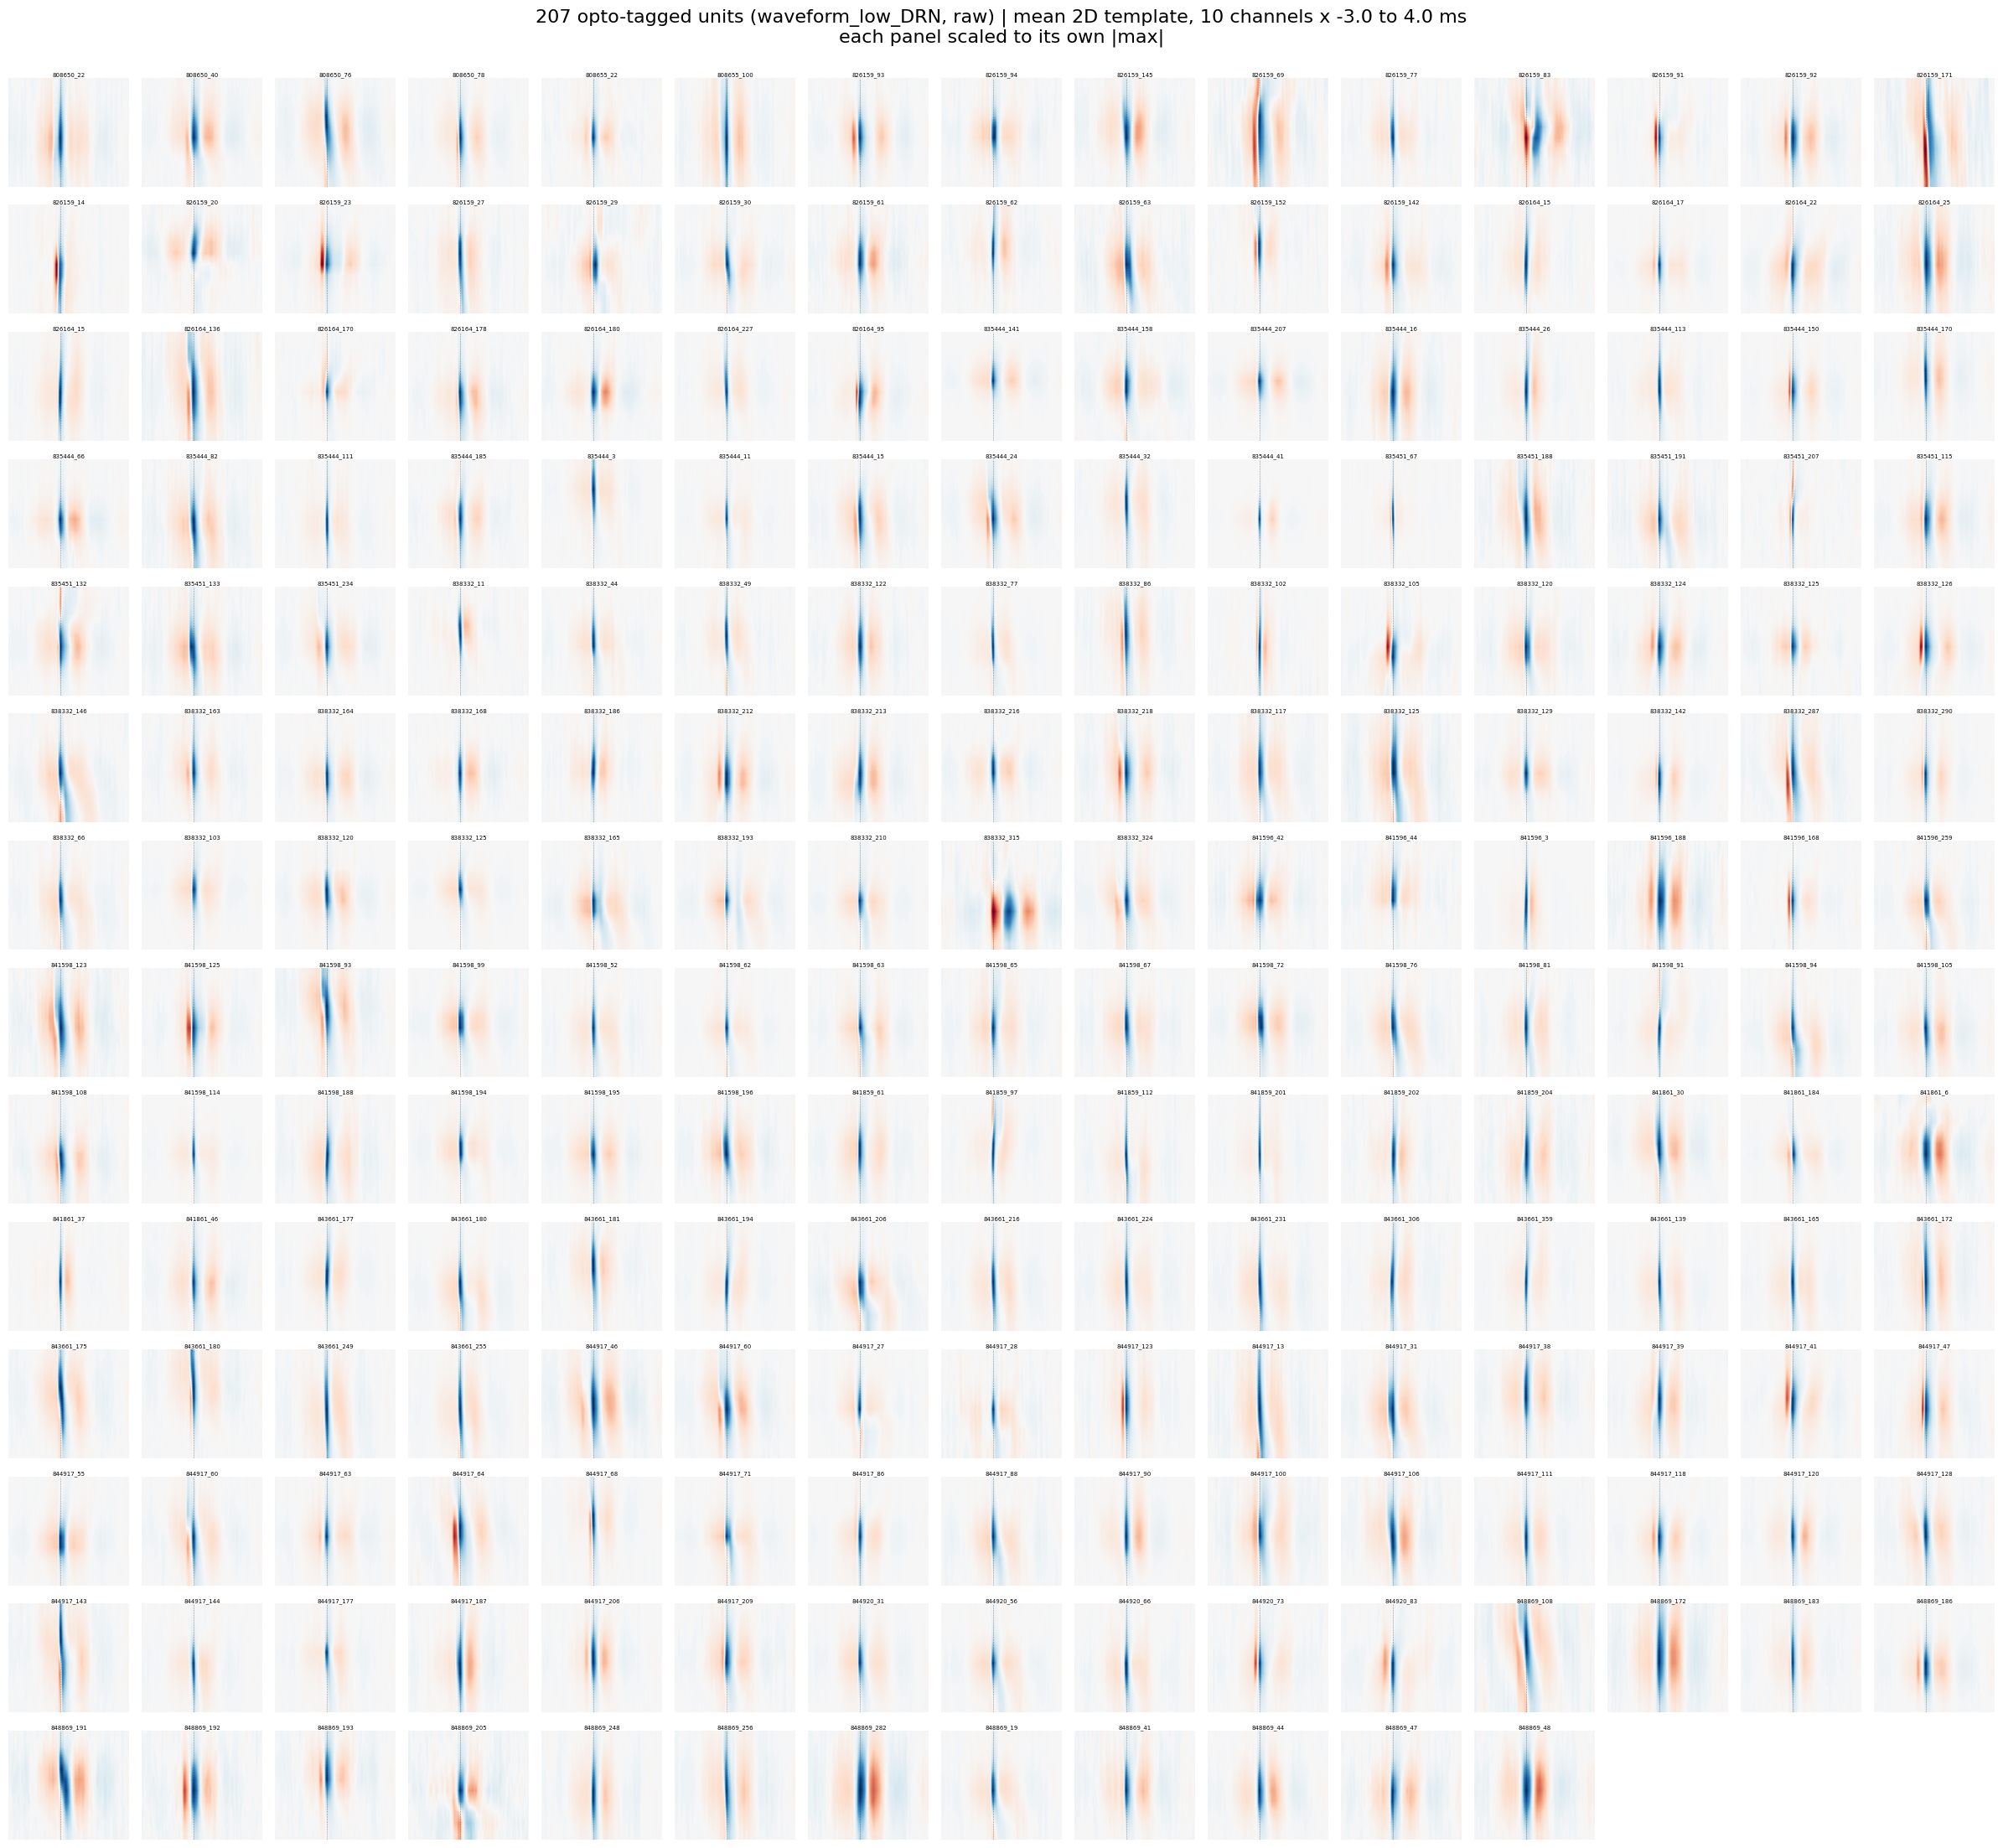

Grid: 207 units (15x15)
Saved: /root/capsule/scratch/results/manuscript/figures/inspect_2d_waveforms_grid_DRN/All_2d_templates_grid_waveform_low_DRN_raw.pdf / .png


In [12]:
n_units = len(template_tbl)
grid_size = int(np.ceil(np.sqrt(n_units)))

global_vmax = max(np.nanmax(np.abs(wf)) for wf in template_tbl['template_2d'])

fig = plt.figure(figsize=(24, 24))
gs = gridspec.GridSpec(grid_size, grid_size, figure=fig)

for i, row in template_tbl.iterrows():
    template_2d = row['template_2d']
    n_samples, n_channels = template_2d.shape
    wf_time = (np.arange(n_samples) - row['nbefore']) / row['fs'] * 1000  # ms

    vmax = np.nanmax(np.abs(template_2d)) if normalize_each_panel else global_vmax

    ax = fig.add_subplot(gs[i])
    ax.imshow(
        template_2d.T,
        aspect='auto',
        cmap='RdBu_r',
        vmin=-vmax,
        vmax=vmax,
        extent=[wf_time[0], wf_time[-1], n_channels, 0],
        interpolation='bilinear',
    )
    ax.axvline(0, color='k', linestyle='--', linewidth=0.4, alpha=0.4)
    ax.set_title(row['label'], fontsize=label_fontsize, pad=1)

    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)

scale_str = 'each panel scaled to its own |max|' if normalize_each_panel else f'shared scale +/-{global_vmax:.0f} uV'
example = template_tbl.iloc[0]
window_str = (
    f"{-example['nbefore'] / example['fs'] * 1000:.1f} to "
    f"{(example['template_2d'].shape[0] - example['nbefore']) / example['fs'] * 1000:.1f} ms"
)
title = (
    f'{n_units} opto-tagged units ({criteria_name}, {data_type}) | '
    f'mean 2D template, {n_channels_to_show} channels x {window_str}\n{scale_str}'
)
plt.suptitle(title, fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.98])

fig_stem = os.path.join(target_folder, f'All_2d_templates_grid_{criteria_name}_{data_type}')
fig.savefig(f'{fig_stem}.pdf', dpi=150, bbox_inches='tight')
fig.savefig(f'{fig_stem}.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Grid: {n_units} units ({grid_size}x{grid_size})')
print(f'Saved: {fig_stem}.pdf / .png')

## 7. Optional: one grid page per session

Same panels, split by session, when the combined grid gets too dense to read.

In [ ]:
save_per_session = False  # set True to write one PDF per session

if save_per_session:
    per_session_folder = os.path.join(target_folder, 'per_session')
    os.makedirs(per_session_folder, exist_ok=True)

    for session, session_tbl in template_tbl.groupby('session'):
        session_tbl = session_tbl.reset_index(drop=True)
        n_cols = min(6, len(session_tbl))
        n_rows = int(np.ceil(len(session_tbl) / n_cols))

        fig, axes = plt.subplots(n_rows, n_cols, figsize=(2.2 * n_cols, 2.2 * n_rows), squeeze=False)
        for ax in axes.flatten():
            ax.axis('off')

        for i, row in session_tbl.iterrows():
            template_2d = row['template_2d']
            n_samples, n_channels = template_2d.shape
            wf_time = (np.arange(n_samples) - row['nbefore']) / row['fs'] * 1000
            vmax = np.nanmax(np.abs(template_2d))

            ax = axes[i // n_cols, i % n_cols]
            ax.axis('on')
            ax.imshow(
                template_2d.T,
                aspect='auto',
                cmap='RdBu_r',
                vmin=-vmax,
                vmax=vmax,
                extent=[wf_time[0], wf_time[-1], n_channels, 0],
                interpolation='bilinear',
            )
            ax.axvline(0, color='k', linestyle='--', linewidth=0.5, alpha=0.5)
            ax.set_title(f"unit {row['unit']}\n{row['amp']:.0f} uV", fontsize=8)
            ax.set_xticks([])
            ax.set_yticks([])

        fig.suptitle(f'{session} | mean 2D templates ({len(session_tbl)} tagged units)', fontsize=11)
        fig.tight_layout(rect=[0, 0, 1, 0.96])
        fig.savefig(os.path.join(per_session_folder, f'{session}_2d_templates_grid.pdf'), bbox_inches='tight')
        plt.close(fig)

    print(f'Saved per-session grids to {per_session_folder}')